import sys
import glob
import os

import numpy as np
import torch
import torch.serialization
import matplotlib.pyplot as plt

# MONAI MetaTensor embeds numpy affine/metadata; allowlist for PyTorch 2.6+
torch.serialization.add_safe_globals([
    np._core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
])

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from moco.CTMoCoDataset import CTMoCoDataset


In [20]:
import sys
import glob
import os

import torch
import matplotlib.pyplot as plt
import numpy as np

# Add project root so we can import moco package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from moco.CTMoCoDataset import CTMoCoDataset

## 1. Set paths to cached tensors

Copy a few sample `.pt` files from HPC scratch to a local directory, or point
directly at the scratch mount if available:

```bash
# Example: pull 5 samples from each dataset
mkdir -p ~/Projects/data/sample-tensors/CT\ COLONOGRAPHY
mkdir -p ~/Projects/data/sample-tensors/Pediatric-CT-SEG
scp hpc:/scratch/jpbunnel/cached-tensors/CT\ COLONOGRAPHY/*.pt | head -5  ~/Projects/data/sample-tensors/CT\ COLONOGRAPHY/
scp hpc:/scratch/jpbunnel/cached-tensors/Pediatric-CT-SEG/*.pt | head -5  ~/Projects/data/sample-tensors/Pediatric-CT-SEG/
```

In [21]:
# Point this at wherever your cached .pt files live
CACHE_DIR = "/Users/joshuabunnell/Projects/data/dicom/cached-tensors/CT COLONGRAPHY"

# Discover all .pt files
pt_files = sorted(glob.glob(os.path.join(CACHE_DIR, "**/*.pt"), recursive=True))
print(f"Found {len(pt_files)} cached tensors")

# Group by dataset
by_dataset = {}
for f in pt_files:
    dataset_name = os.path.basename(os.path.dirname(f))
    by_dataset.setdefault(dataset_name, []).append(f)

for name, files in by_dataset.items():
    print(f"  {name}: {len(files)} tensors")

Found 4 cached tensors
  CT COLONGRAPHY: 4 tensors


## 2. Inspect individual tensors

Verify shape, dtype, and value range. Expected:
- Shape: `(1, H, W, D)` — varies per volume after 1mm resampling
- Dtype: `float32`
- Values: `[0.0, 1.0]` — soft-tissue windowed and clipped

In [22]:
N_SAMPLES = 5  # Number of samples to inspect per dataset

for dataset_name, files in by_dataset.items():
    print(f"\n=== {dataset_name} ===")
    for f in files[:N_SAMPLES]:
        vol = torch.load(f, weights_only=False)
        print(
            f"  {os.path.basename(f)[:16]}...  "
            f"shape={tuple(vol.shape)}  "
            f"dtype={vol.dtype}  "
            f"min={vol.min():.4f}  max={vol.max():.4f}  "
            f"mean={vol.float().mean():.4f}"
        )


=== CT COLONGRAPHY ===
  009dfa7600b0d7a0...  shape=(1, 400, 400, 414)  dtype=torch.float32  min=0.0000  max=1.0000  mean=0.1477
  09217d360d433bfb...  shape=(1, 360, 360, 426)  dtype=torch.float32  min=0.0000  max=1.0000  mean=0.1587
  1cab5755cc33f8be...  shape=(1, 367, 367, 446)  dtype=torch.float32  min=0.0000  max=1.0000  mean=0.1510
  23cc31f783fbda3e...  shape=(1, 400, 400, 494)  dtype=torch.float32  min=0.0000  max=1.0000  mean=0.1648


## 3. Visualize middle slices

Show the axial middle slice from each sampled volume.
Should look like a soft-tissue CT cross-section (colon wall, fat visible; bone/air clipped).

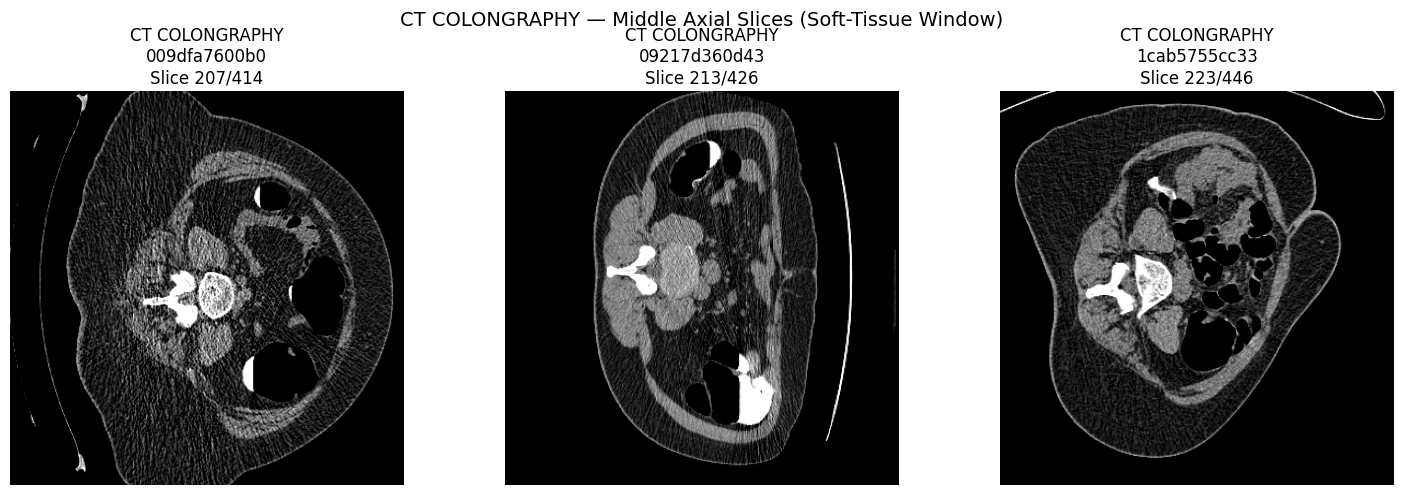

In [ ]:
N_VIS = 4  # Volumes to visualize per dataset

for dataset_name, files in by_dataset.items():
    sample_files = files[:N_VIS]
    fig, axes = plt.subplots(1, len(sample_files), figsize=(5 * len(sample_files), 5))
    if len(sample_files) == 1:
        axes = [axes]

    for ax, f in zip(axes, sample_files):
        vol = torch.load(f, weights_only=False)
        # Middle axial slice: vol is (1, H, W, D)
        slice_idx = vol.shape[-1] // 2
        ax.imshow(vol[0, :, :, slice_idx].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(
            f"{dataset_name}\n{os.path.basename(f)[:12]}\nSlice {slice_idx}/{vol.shape[-1]}"
        )
        ax.axis("off")

    plt.suptitle(
        f"{dataset_name} — Middle Axial Slices (Soft-Tissue Window)", fontsize=14
    )
    plt.tight_layout()
    plt.show()

## 4. Multi-plane visualization

Show axial, sagittal, and coronal views of one volume to confirm RAS orientation.

In [24]:
# Pick one volume from the first dataset
sample_path = list(by_dataset.values())[0][0]
vol = torch.load(sample_path, weights_only=True)
print(f"Volume: {os.path.basename(sample_path)}  Shape: {tuple(vol.shape)}")

img = vol[0]  # Remove channel dim: (H, W, D)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial (slice through D)
ax_idx = img.shape[2] // 2
axes[0].imshow(img[:, :, ax_idx].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Axial (D={ax_idx})")

# Sagittal (slice through W)
sag_idx = img.shape[1] // 2
axes[1].imshow(img[:, sag_idx, :].numpy(), cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[1].set_title(f"Sagittal (W={sag_idx})")

# Coronal (slice through H)
cor_idx = img.shape[0] // 2
axes[2].imshow(img[cor_idx, :, :].numpy(), cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[2].set_title(f"Coronal (H={cor_idx})")

for ax in axes:
    ax.axis("off")

plt.suptitle("RAS Orientation Check — Three Planes", fontsize=14)
plt.tight_layout()
plt.show()

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

## 5. Test CTMoCoDataset

Validate that the dataset class loads tensors correctly and produces valid contrastive pairs.

In [ ]:
# CTMoCoDataset expects a directory; it globs for **/*.pt recursively
dataset = CTMoCoDataset(CACHE_DIR)
print(f"Dataset length: {len(dataset)}")

In [ ]:
# Pull a few samples and validate
N_TEST = 3

for i in range(N_TEST):
    (view_q, view_k), target = dataset[i]
    print(
        f"Sample {i}: "
        f"q={tuple(view_q.shape)} [{view_q.min():.3f}, {view_q.max():.3f}]  "
        f"k={tuple(view_k.shape)} [{view_k.min():.3f}, {view_k.max():.3f}]  "
        f"target={target}"
    )
    # Verify shapes match ResNet input: (3, 224, 224)
    assert view_q.shape == (3, 224, 224), f"Bad query shape: {view_q.shape}"
    assert view_k.shape == (3, 224, 224), f"Bad key shape: {view_k.shape}"
    assert view_q.dtype == torch.float32
    # Views should differ (independent augmentations)
    assert not torch.equal(view_q, view_k), (
        "Query and key are identical — augmentations not working"
    )

print("\nAll checks passed!")

In [ ]:
# Visualize a contrastive pair
(view_q, view_k), _ = dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Show all 3 "channels" (adjacent slices) of query view
for c in range(3):
    axes[c].imshow(view_q[c].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[c].set_title(f"Query — Slice {c}")
    axes[c].axis("off")

plt.suptitle("Query View: 3 Adjacent Slices (2.5D Crop)", fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for c in range(3):
    axes[c].imshow(view_k[c].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[c].set_title(f"Key — Slice {c}")
    axes[c].axis("off")

plt.suptitle("Key View: 3 Adjacent Slices (2.5D Crop)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. DataLoader smoke test

Verify that batching works correctly (important before launching full training).

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,  # 0 for notebook; training uses more
    drop_last=True,
)

batch = next(iter(loader))
images, targets = batch
# images is a list of [query_batch, key_batch]
print(f"Batch query shape:  {images[0].shape}")  # (4, 3, 224, 224)
print(f"Batch key shape:    {images[1].shape}")  # (4, 3, 224, 224)
print(f"Targets:            {targets}")

assert images[0].shape == (4, 3, 224, 224)
assert images[1].shape == (4, 3, 224, 224)
print("\nDataLoader batch check passed!")